In [17]:
import pandas as pd

# Step 1: Read contractor data
df = pd.read_csv("/content/Contractor Performance Data - Cleaned.csv")

# Step 2: Sort contractors by 'Sales Target Hit (₹)' in descending order
df_sorted = df.sort_values(by='Sales Target Hit(₹)', ascending=False)

# Step 3: Compute baseline total revenue
baseline = df_sorted['Sales Target Hit(₹)'].sum() #Only A-List contractors

print('Scenario A:(A-List Only, ₹1.57Cr)')
print('-------------------------------------------------------')
# Step 4: Choose top-N contractors
for top_n in [5, 10, 20]:
    top_contractors = df_sorted.head(top_n)
    for drop_pct in [0.25, 0.50, 0.75]:
        # Step 5: Simulate partial drop
        drop_amount = top_contractors['Sales Target Hit(₹)'].sum() * drop_pct
        revenue_after = baseline - drop_amount
        revenue_loss_pct = (drop_amount / baseline) * 100

        print(f"Top-{top_n} with {int(drop_pct*100)}% drop → Revenue Loss ₹{drop_amount:,.0f} ({revenue_loss_pct:.2f}%)")


Scenario A:(A-List Only, ₹1.57Cr)
-------------------------------------------------------
Top-5 with 25% drop → Revenue Loss ₹802,716 (5.10%)
Top-5 with 50% drop → Revenue Loss ₹1,605,432 (10.21%)
Top-5 with 75% drop → Revenue Loss ₹2,408,149 (15.31%)
Top-10 with 25% drop → Revenue Loss ₹1,358,262 (8.64%)
Top-10 with 50% drop → Revenue Loss ₹2,716,524 (17.28%)
Top-10 with 75% drop → Revenue Loss ₹4,074,786 (25.91%)
Top-20 with 25% drop → Revenue Loss ₹2,134,126 (13.57%)
Top-20 with 50% drop → Revenue Loss ₹4,268,252 (27.14%)
Top-20 with 75% drop → Revenue Loss ₹6,402,379 (40.72%)


In [16]:
import pandas as pd

# Step 1: Read contractor data
df = pd.read_csv("/content/Contractor Performance Data - Cleaned.csv")

# Step 2: Sort contractors by 'Sales Target Hit (₹)' in descending order
df_sorted = df.sort_values(by='Sales Target Hit(₹)', ascending=False)

# Step 3: Compute baseline total revenue
baseline = 24000000 #(estimate directly provided from the proprietor)
print('Scenario B:(Full Channel, ₹2.4Cr)')
print('-------------------------------------------------------')
# Step 4: Choose top-N contractors
for top_n in [5, 10, 20, 67]:
    top_contractors = df_sorted.head(top_n)
    for drop_pct in [0.25, 0.50, 0.75]:
        # Step 5: Simulate partial drop
        drop_amount = top_contractors['Sales Target Hit(₹)'].sum() * drop_pct
        revenue_after = baseline - drop_amount
        revenue_loss_pct = (drop_amount / baseline) * 100

        print(f"Top-{top_n} with {int(drop_pct*100)}% drop → Revenue Loss ₹{drop_amount:,.0f} ({revenue_loss_pct:.2f}%)")


Scenario B:(Full Channel, ₹2.4Cr)
-------------------------------------------------------
Top-5 with 25% drop → Revenue Loss ₹802,716 (3.34%)
Top-5 with 50% drop → Revenue Loss ₹1,605,432 (6.69%)
Top-5 with 75% drop → Revenue Loss ₹2,408,149 (10.03%)
Top-10 with 25% drop → Revenue Loss ₹1,358,262 (5.66%)
Top-10 with 50% drop → Revenue Loss ₹2,716,524 (11.32%)
Top-10 with 75% drop → Revenue Loss ₹4,074,786 (16.98%)
Top-20 with 25% drop → Revenue Loss ₹2,134,126 (8.89%)
Top-20 with 50% drop → Revenue Loss ₹4,268,252 (17.78%)
Top-20 with 75% drop → Revenue Loss ₹6,402,379 (26.68%)
Top-67 with 25% drop → Revenue Loss ₹3,931,154 (16.38%)
Top-67 with 50% drop → Revenue Loss ₹7,862,307 (32.76%)
Top-67 with 75% drop → Revenue Loss ₹11,793,460 (49.14%)


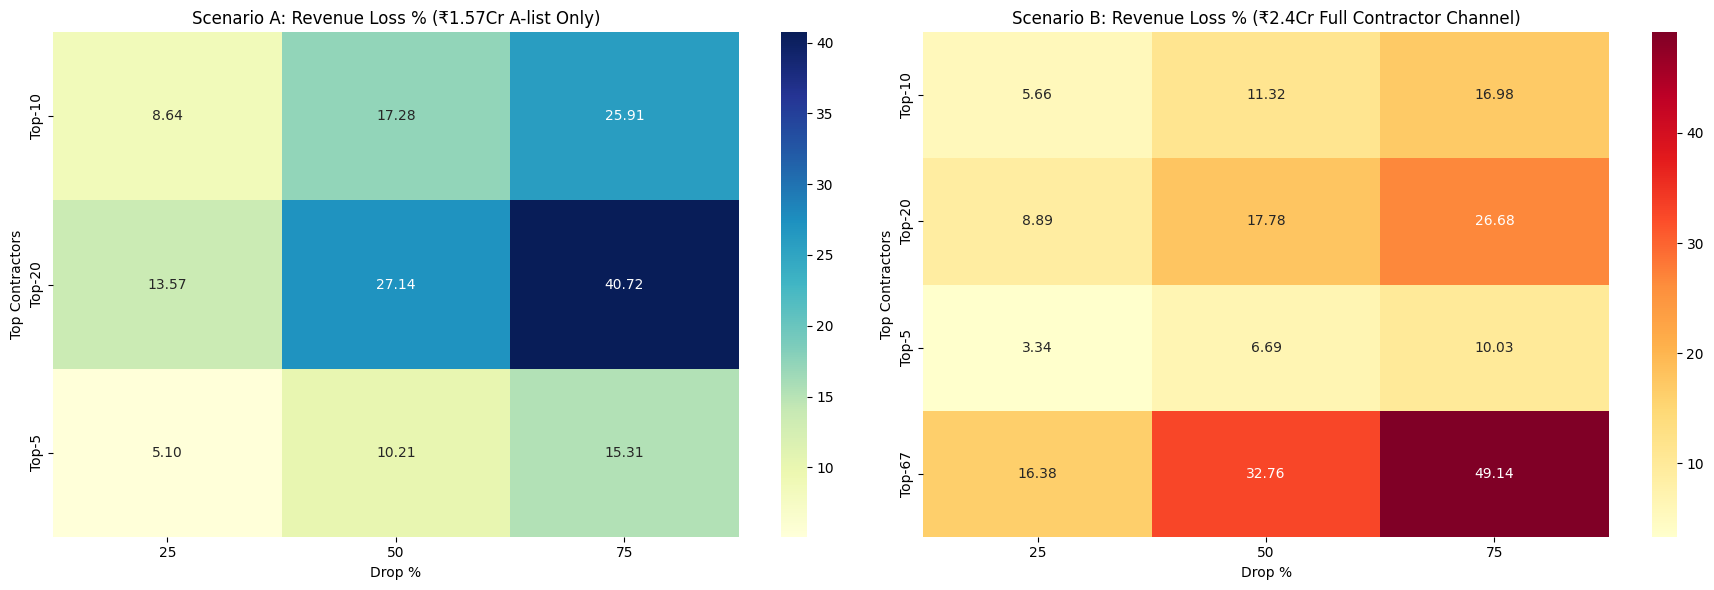

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated data for Scenario A (A-list Only, ₹1.57Cr)
data1 = {
    'Top Contractors': ['Top-5', 'Top-5', 'Top-5', 'Top-10', 'Top-10', 'Top-10', 'Top-20', 'Top-20', 'Top-20'],
    'Drop %': [25, 50, 75, 25, 50, 75, 25, 50, 75],
    'Revenue Loss (%)': [5.10, 10.21, 15.31, 8.64, 17.28, 25.91, 13.57, 27.14, 40.72]
}
df1 = pd.DataFrame(data1)

# Updated data for Scenario B (Full Channel, ₹2.4Cr)
data2 = {
    'Top Contractors': ['Top-5', 'Top-5', 'Top-5', 'Top-10', 'Top-10', 'Top-10',
                        'Top-20', 'Top-20', 'Top-20', 'Top-67', 'Top-67', 'Top-67'],
    'Drop %': [25, 50, 75, 25, 50, 75, 25, 50, 75, 25, 50, 75],
    'Revenue Loss (%)': [3.34, 6.69, 10.03, 5.66, 11.32, 16.98,
                         8.89, 17.78, 26.68, 16.38, 32.76, 49.14]
}
df2 = pd.DataFrame(data2)

# Create pivot tables
pivot1 = df1.pivot(index='Top Contractors', columns='Drop %', values='Revenue Loss (%)')
pivot2 = df2.pivot(index='Top Contractors', columns='Drop %', values='Revenue Loss (%)')

# Side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot1, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[0])
axes[0].set_title('Scenario A: Revenue Loss % (₹1.57Cr A-list Only)')

sns.heatmap(pivot2, annot=True, cmap='YlOrRd', fmt='.2f', ax=axes[1])
axes[1].set_title('Scenario B: Revenue Loss % (₹2.4Cr Full Contractor Channel)')

plt.tight_layout()
plt.show()


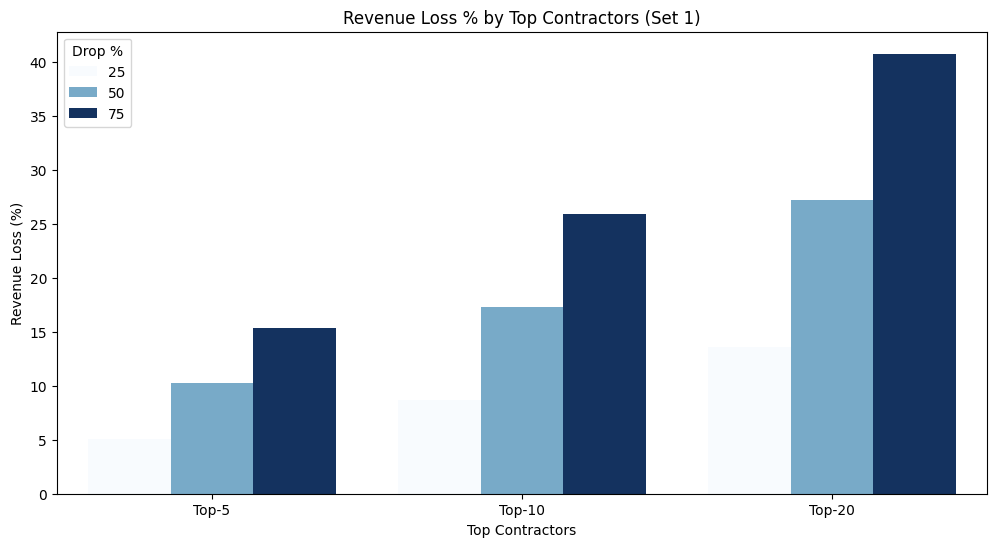

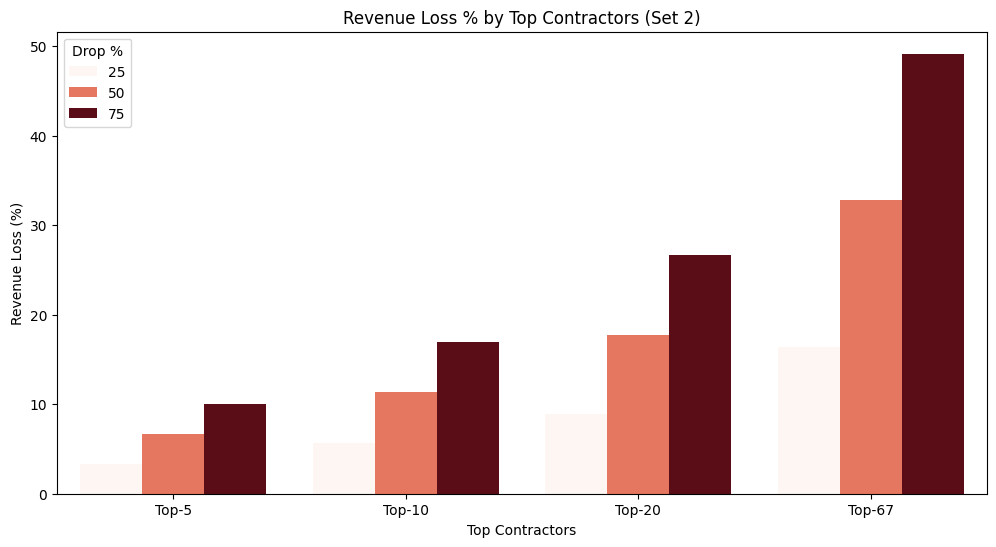

In [36]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Top Contractors', y='Revenue Loss (%)', hue='Drop %', data=df1, palette='Blues')
plt.title('Revenue Loss % by Top Contractors (Set 1)')
plt.xlabel('Top Contractors')
plt.ylabel('Revenue Loss (%)')
plt.legend(title='Drop %')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Top Contractors', y='Revenue Loss (%)', hue='Drop %', data=df2, palette='Reds')
plt.title('Revenue Loss % by Top Contractors (Set 2)')
plt.xlabel('Top Contractors')
plt.ylabel('Revenue Loss (%)')
plt.legend(title='Drop %')
plt.show()

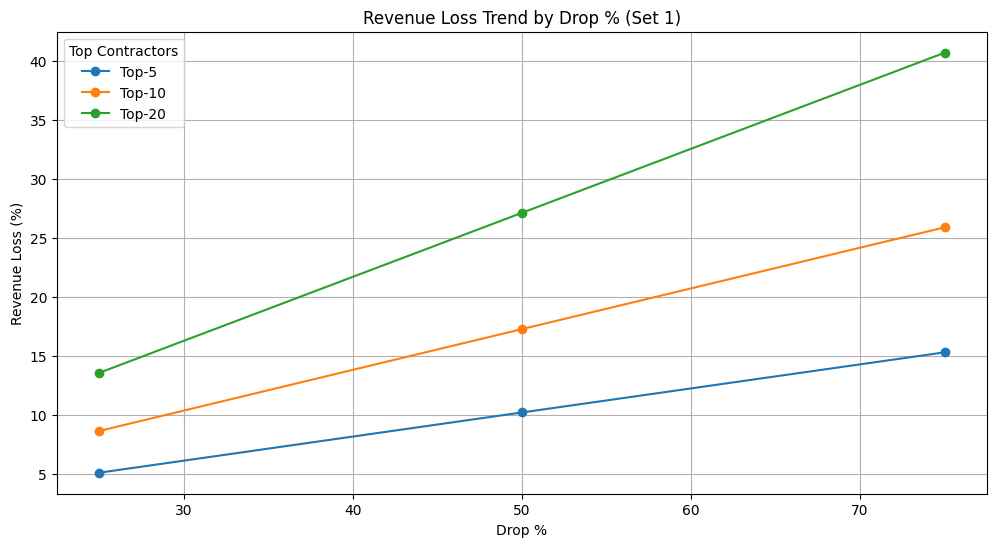

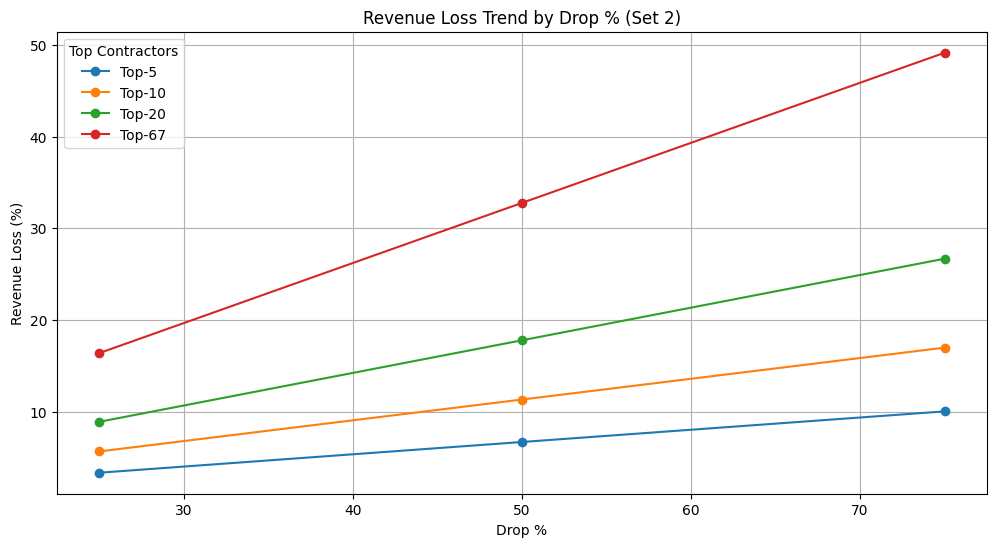

In [37]:
plt.figure(figsize=(12, 6))
for top in df1['Top Contractors'].unique():
    subset = df1[df1['Top Contractors'] == top]
    plt.plot(subset['Drop %'], subset['Revenue Loss (%)'], marker='o', label=top)
plt.title('Revenue Loss Trend by Drop % (Set 1)')
plt.xlabel('Drop %')
plt.ylabel('Revenue Loss (%)')
plt.legend(title='Top Contractors')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for top in df2['Top Contractors'].unique():
    subset = df2[df2['Top Contractors'] == top]
    plt.plot(subset['Drop %'], subset['Revenue Loss (%)'], marker='o', label=top)
plt.title('Revenue Loss Trend by Drop % (Set 2)')
plt.xlabel('Drop %')
plt.ylabel('Revenue Loss (%)')
plt.legend(title='Top Contractors')
plt.grid(True)
plt.show()

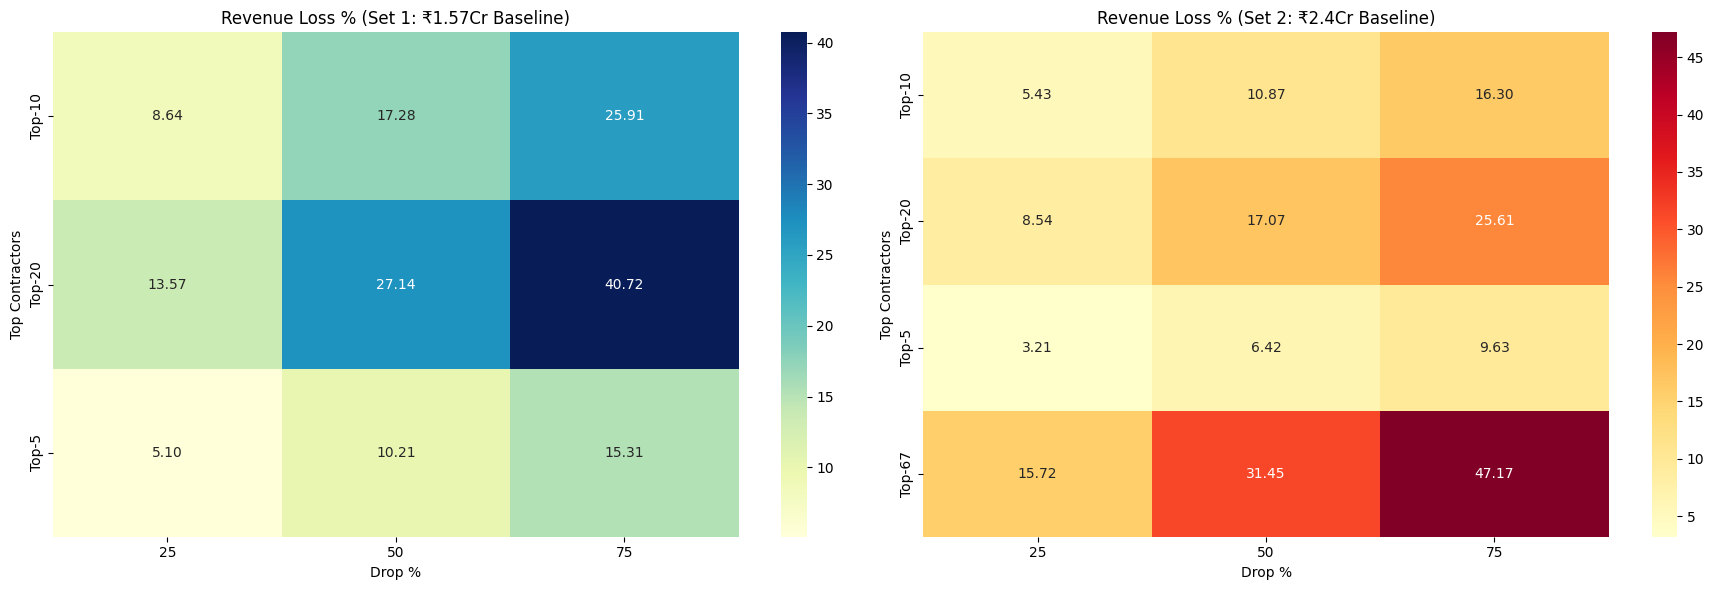

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the pivot tables (you've already done this)
pivot1 = df1.pivot(index='Top Contractors', columns='Drop %', values='Revenue Loss (%)')
pivot2 = df2.pivot(index='Top Contractors', columns='Drop %', values='Revenue Loss (%)')

# Set up the subplot grid
fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 row, 2 columns

# First heatmap (Set 1)
sns.heatmap(pivot1, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[0])
axes[0].set_title('Revenue Loss % (Set 1: ₹1.57Cr Baseline)')

# Second heatmap (Set 2)
sns.heatmap(pivot2, annot=True, cmap='YlOrRd', fmt='.2f', ax=axes[1])
axes[1].set_title('Revenue Loss % (Set 2: ₹2.4Cr Baseline)')

# Layout adjustment
plt.tight_layout()
plt.show()


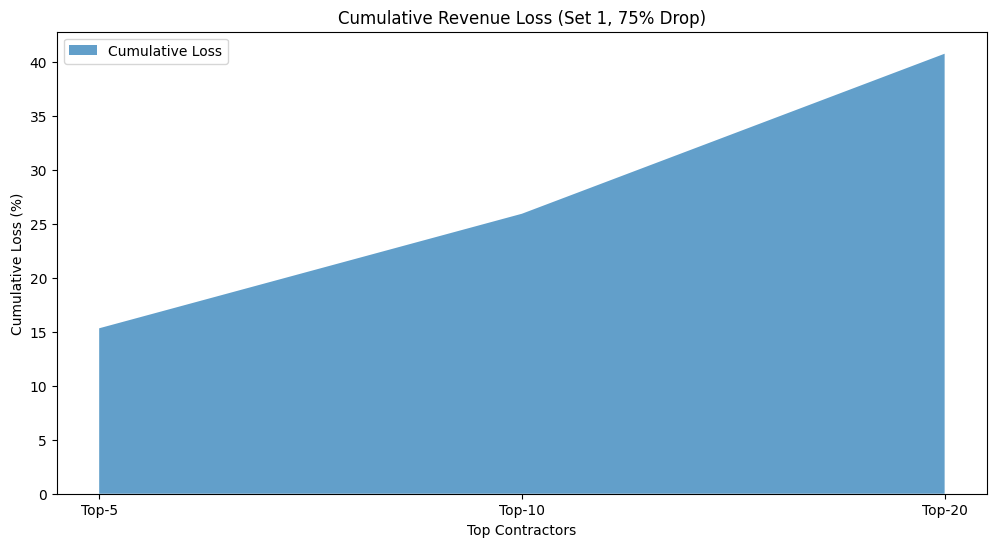

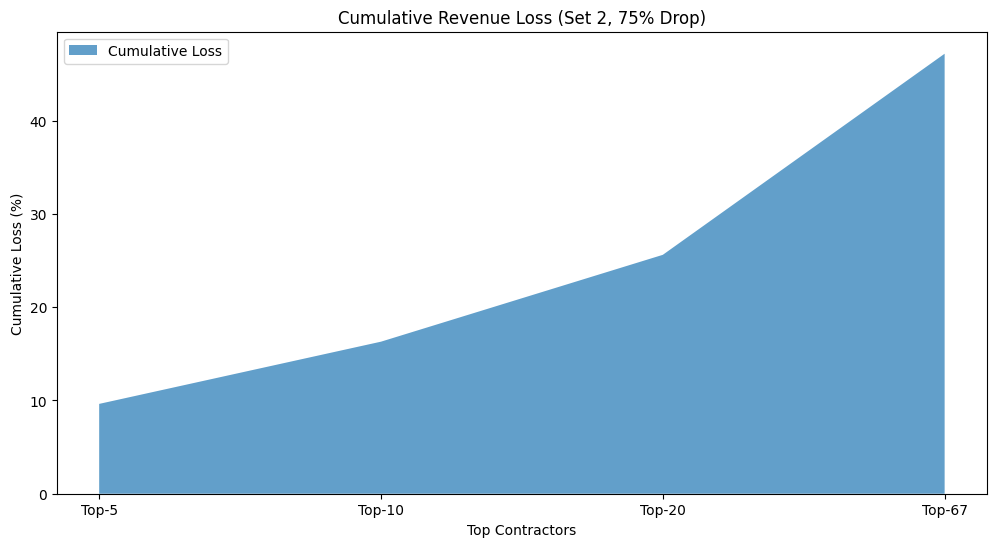

In [38]:
# Cumulative loss by top group at 75% drop
cum_data1 = {'Top Contractors': ['Top-5', 'Top-10', 'Top-20'], 'Cum Loss (%)': [15.31, 25.91, 40.72]}
cum_data2 = {'Top Contractors': ['Top-5', 'Top-10', 'Top-20', 'Top-67'], 'Cum Loss (%)': [9.63, 16.30, 25.61, 47.17]}
df_cum1 = pd.DataFrame(cum_data1)
df_cum2 = pd.DataFrame(cum_data2)

plt.figure(figsize=(12, 6))
plt.stackplot(df_cum1['Top Contractors'], df_cum1['Cum Loss (%)'], labels=['Cumulative Loss'], alpha=0.7)
plt.title('Cumulative Revenue Loss (Set 1, 75% Drop)')
plt.xlabel('Top Contractors')
plt.ylabel('Cumulative Loss (%)')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.stackplot(df_cum2['Top Contractors'], df_cum2['Cum Loss (%)'], labels=['Cumulative Loss'], alpha=0.7)
plt.title('Cumulative Revenue Loss (Set 2, 75% Drop)')
plt.xlabel('Top Contractors')
plt.ylabel('Cumulative Loss (%)')
plt.legend()
plt.show()

In [39]:

import plotly.graph_objects as go


# Incremental loss for Set 2 at 75% drop
waterfall_data = {
    'Stage': ['Start', 'Top-5', 'Top-10', 'Top-20', 'Top-67'],
    'Change': [0, -2408149, -1665637, -2327593, -5391081]  # Differences in loss
}
df_waterfall = pd.DataFrame(waterfall_data)


fig = go.Figure(go.Waterfall(
    name="Revenue Loss", orientation="v",
    measure=['relative', 'relative', 'relative', 'relative', 'total'],
    x=df_waterfall['Stage'],
    y=df_waterfall['Change'],
    textposition="outside",
    text=[f"{x:,.0f}" for x in df_waterfall['Change']],
    connector={"line": {"color": "rgb(63, 63, 63)"}}
))
fig.update_layout(title='Waterfall Chart of Revenue Loss (Set 2, 75% Drop)',
                  yaxis_title="Revenue Loss (₹)", xaxis_title="Churn Stage")
fig.show()